les imports

In [1]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#from google.colab import files

téléversement du fichier csv

In [4]:
#uploaded = files.upload()

#df = pd.read_csv(next(iter(uploaded)))
df = pd.read_csv('dataset_nlp_test_tal.csv')

Comprendre les données
et comptages des catégories disponible




In [5]:
df.shape
df.head()
df.info()
df["categorie"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   id         150 non-null    int64
 1   texte      150 non-null    str  
 2   categorie  150 non-null    str  
dtypes: int64(1), str(2)
memory usage: 14.7 KB


categorie
Insatisfaction    50
Suggestion        50
Satisfaction      50
Name: count, dtype: int64

verification

In [6]:
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

1. Affichage du nombre de commentaires et de colone du fichier csv

In [7]:
print("Nombre de commentaires :", len(df))
print("Nombre de colonnes :", len(df.columns))

Nombre de commentaires : 150
Nombre de colonnes : 3


2. Identification des catégories

In [8]:
print("Catégories présentes :")
print(df["categorie"].unique())

Catégories présentes :
<ArrowStringArray>
['Insatisfaction', 'Suggestion', 'Satisfaction']
Length: 3, dtype: str


3. Vérification de la distribution des classes

In [9]:
distribution = df["categorie"].value_counts()

print(distribution)

categorie
Insatisfaction    50
Suggestion        50
Satisfaction      50
Name: count, dtype: int64


pourcentage de chaque categories

In [10]:
print(df["categorie"].value_counts(normalize=True) * 100)

categorie
Insatisfaction    33.333333
Suggestion        33.333333
Satisfaction      33.333333
Name: proportion, dtype: float64


4. Calcule de la longueur moyenne des textes

In [11]:
df["longueur_texte"] = df["texte"].str.len()

longueur_moyenne = df.groupby("categorie")["longueur_texte"].mean()

print(longueur_moyenne)

categorie
Insatisfaction    57.76
Satisfaction      57.40
Suggestion        69.82
Name: longueur_texte, dtype: float64


5. le graphe pour obtenir les points de visualisation

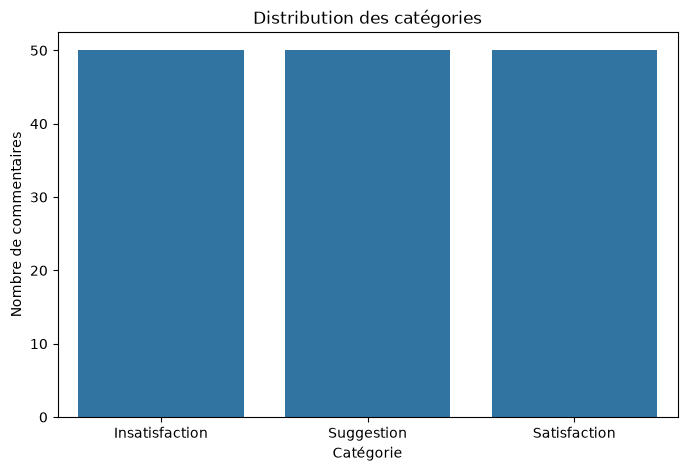

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="categorie")

plt.title("Distribution des catégories")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de commentaires")

plt.show()

Conclusion de l'exploration :
Le dataset contient 150 commentaires répartis de manière équilibrée entre Satisfaction, Insatisfaction et Suggestion. Aucun déséquilibre majeur entre les classes n'est observé. Les commentaires de type Suggestion sont en moyenne plus longs que ceux des deux autres catégories. Ces premières observations permettront d'orienter les étapes suivantes de nettoyage, de vectorisation et de classification.

1.2 — Nettoyage du texte

mettons tous ls blocs en miniscule

creation d'une nouvelle colonne text pour conserver l'originale afin de pouvoir comparer a la fin

In [13]:
df["texte_nettoye"] = df["texte"].str.lower()

verification du resultat obtenue



In [108]:
df[["texte", "texte_nettoye"]].head(10)

,texte,texte_nettoye
0,Manque total de communication entre les services.,manque total de communication entre les services.
1,Il serait bien de proposer des tutoriels vidéo...,il serait bien de proposer des tutoriels vidéo...
2,Envoyer des SMS de confirmation lors de chaque...,envoyer des sms de confirmation lors de chaque...
3,Prévoir des interprètes pour les citoyens ne p...,prévoir des interprètes pour les citoyens ne p...
4,Le formulaire en ligne plante au moment de la ...,le formulaire en ligne plante au moment de la ...
5,Le personnel semble débordé et les citoyens en...,le personnel semble débordé et les citoyens en...
6,Former les agents sur les droits des usagers p...,former les agents sur les droits des usagers p...
7,J'ai été agréablement surpris par la rapidité ...,j'ai été agréablement surpris par la rapidité ...
8,"Bonne expérience globale, les choses évoluent ...","bonne expérience globale, les choses évoluent ..."
9,Le personnel fait preuve de beaucoup de profes...,le personnel fait preuve de beaucoup de profes...


suppression de la ponctuation, les chiffres et les caractères spéciaux

In [14]:
import re

creons une fonnction de netyage de carractere

On conserve les lettres accentuées comme é, è, à, ô, etc., ce qui est important pour le français. On ne supprime pas non plus les lettres des mots éwé/mina.

In [15]:
import string

def nettoyer_caracteres(texte):
    texte = re.sub(r"[^\w\s]", " ", texte, flags=re.UNICODE)
    texte = re.sub(r"\d+", " ", texte)
    texte = re.sub(r"_", " ", texte)
    texte = re.sub(r"\s+", " ", texte)
    return texte.strip()

applicons la fonction a notre sujet

In [16]:
df["texte_nettoye"] = df["texte_nettoye"].apply(nettoyer_caracteres)

verification de du netoyage

In [17]:
df[["texte", "texte_nettoye"]].head(10)

,texte,texte_nettoye
0,Manque total de communication entre les services.,manque total de communication entre les services
1,Il serait bien de proposer des tutoriels vidéo...,il serait bien de proposer des tutoriels vidéo...
2,Envoyer des SMS de confirmation lors de chaque...,envoyer des sms de confirmation lors de chaque...
3,Prévoir des interprètes pour les citoyens ne p...,prévoir des interprètes pour les citoyens ne p...
4,Le formulaire en ligne plante au moment de la ...,le formulaire en ligne plante au moment de la ...
5,Le personnel semble débordé et les citoyens en...,le personnel semble débordé et les citoyens en...
6,Former les agents sur les droits des usagers p...,former les agents sur les droits des usagers p...
7,J'ai été agréablement surpris par la rapidité ...,j ai été agréablement surpris par la rapidité ...
8,"Bonne expérience globale, les choses évoluent ...",bonne expérience globale les choses évoluent p...
9,Le personnel fait preuve de beaucoup de profes...,le personnel fait preuve de beaucoup de profes...


On va installer et charger les stopwords français.

In [18]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/koudousse/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

vérification des stopwords pour voir quels mots de notre dataset seront concernés.

In [19]:
from nltk.corpus import stopwords

stopwords_fr = set(stopwords.words("french"))

negations = {
    "ne", "n", "pas", "plus", "jamais",
    "aucun", "aucune", "sans", "ni", "rien"
}

stopwords_fr = stopwords_fr - negations

print(list(stopwords_fr)[:20])

['aviez', 'étés', 'avec', 'j', 'aurai', 'ou', 'seriez', 'du', 'qui', 'sont', 'eusses', 'eurent', 'aurait', 'seront', 'ayons', 'aurions', 'aient', 'il', 'étante', 'que']


faisons une transformation par exemple :

"le personnel fait preuve de beaucoup de professionnalisme"

en :

["le", "personnel", "fait", "preuve", "de", "beaucoup", "de", "professionnalisme"]

manque de mot technique

In [20]:
df["tokens"] = df["texte_nettoye"].str.split()

verification

In [21]:
df[["texte_nettoye", "tokens"]].head()

,texte_nettoye,tokens
0,manque total de communication entre les services,"[manque, total, de, communication, entre, les,..."
1,il serait bien de proposer des tutoriels vidéo...,"[il, serait, bien, de, proposer, des, tutoriel..."
2,envoyer des sms de confirmation lors de chaque...,"[envoyer, des, sms, de, confirmation, lors, de..."
3,prévoir des interprètes pour les citoyens ne p...,"[prévoir, des, interprètes, pour, les, citoyen..."
4,le formulaire en ligne plante au moment de la ...,"[le, formulaire, en, ligne, plante, au, moment..."


Etape de suppression des stopwords
pour chaque commentaire, on parcourt les tokens et on garde uniquement ceux qui ne sont pas dans notre liste de stopwords.

In [22]:
df["tokens_sans_stopwords"] = df["tokens"].apply(
    lambda tokens: [mot for mot in tokens if mot not in stopwords_fr]
)

verification du rendu

In [23]:
df[["tokens", "tokens_sans_stopwords"]].head()

,tokens,tokens_sans_stopwords
0,"[manque, total, de, communication, entre, les,...","[manque, total, communication, entre, services]"
1,"[il, serait, bien, de, proposer, des, tutoriel...","[bien, proposer, tutoriels, vidéo, démarches, ..."
2,"[envoyer, des, sms, de, confirmation, lors, de...","[envoyer, sms, confirmation, lors, chaque, éta..."
3,"[prévoir, des, interprètes, pour, les, citoyen...","[prévoir, interprètes, citoyens, ne, parlant, ..."
4,"[le, formulaire, en, ligne, plante, au, moment...","[formulaire, ligne, plante, moment, soumission]"


Nous allons maintenant transformer la liste de tokens nettoyés en une nouvelle phrase, car les modèles TF-IDF travailleront plus facilement avec une colonne texte.

In [24]:
df["texte_propre"] = df["tokens_sans_stopwords"].apply(" ".join)

verification du rendu

In [25]:
df[["texte", "texte_propre"]].head()

,texte,texte_propre
0,Manque total de communication entre les services.,manque total communication entre services
1,Il serait bien de proposer des tutoriels vidéo...,bien proposer tutoriels vidéo démarches ligne
2,Envoyer des SMS de confirmation lors de chaque...,envoyer sms confirmation lors chaque étape tra...
3,Prévoir des interprètes pour les citoyens ne p...,prévoir interprètes citoyens ne parlant pas fr...
4,Le formulaire en ligne plante au moment de la ...,formulaire ligne plante moment soumission


On Attaque le WordCloud

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

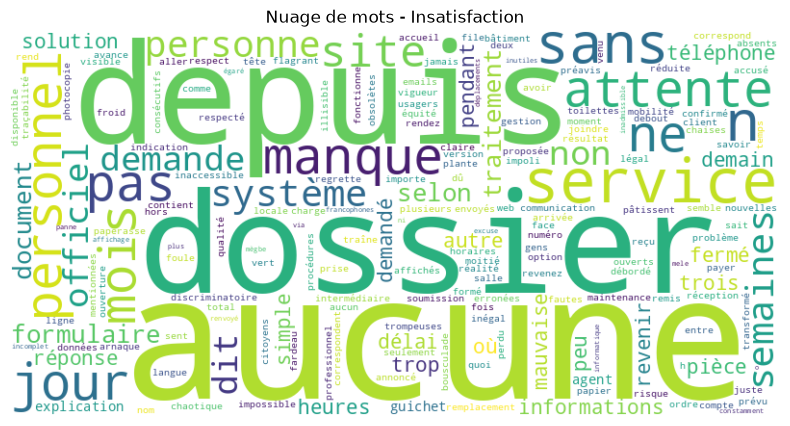

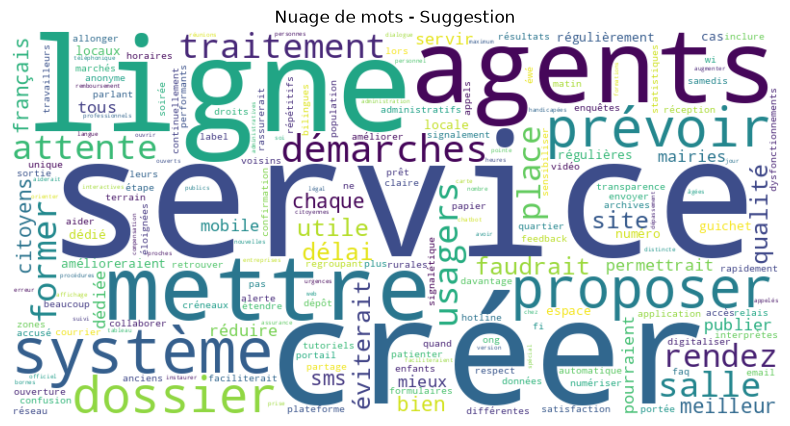

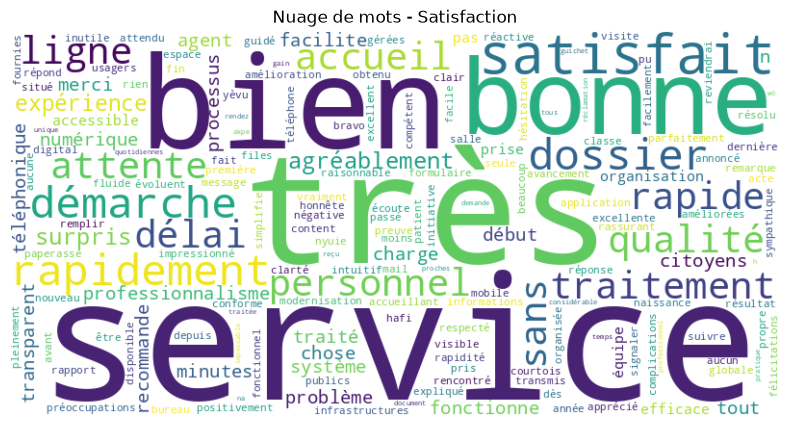

In [27]:
categories = df["categorie"].unique()

for categorie in categories:
    texte = " ".join(
        df[df["categorie"] == categorie]["texte_propre"]
    )

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color="white"
    ).generate(texte)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Nuage de mots - {categorie}")
    plt.show()

On va compter les mots présents dans texte_propre.

In [28]:
from collections import Counter

In [29]:
for categorie in df["categorie"].unique():
    textes = df[df["categorie"] == categorie]["texte_propre"]

    mots = " ".join(textes).split()
    frequences = Counter(mots)

    print(f"\n15 termes les plus fréquents - {categorie}")
    print(frequences.most_common(15))


15 termes les plus fréquents - Insatisfaction
[('aucune', 10), ('a', 8), ('depuis', 6), ('dossier', 6), ('service', 5), ('n', 5), ('sans', 5), ('manque', 4), ('personnel', 4), ('attente', 4), ('pas', 4), ('mois', 4), ('ne', 4), ('site', 3), ('jours', 3)]

15 termes les plus fréquents - Suggestion
[('créer', 6), ('ligne', 5), ('agents', 5), ('services', 5), ('mettre', 5), ('système', 5), ('proposer', 4), ('prévoir', 4), ('démarches', 3), ('traitement', 3), ('former', 3), ('usagers', 3), ('attente', 3), ('rendez', 3), ('place', 3)]

15 termes les plus fréquents - Satisfaction
[('service', 14), ('très', 12), ('bien', 8), ('a', 6), ('bonne', 5), ('satisfait', 4), ('rapidement', 4), ('dossier', 4), ('traitement', 3), ('personnel', 3), ('rapide', 3), ('accueil', 3), ('qualité', 3), ('ligne', 3), ('démarches', 3)]


graphique pour chaque catégorie

Pour une meilleure présentation

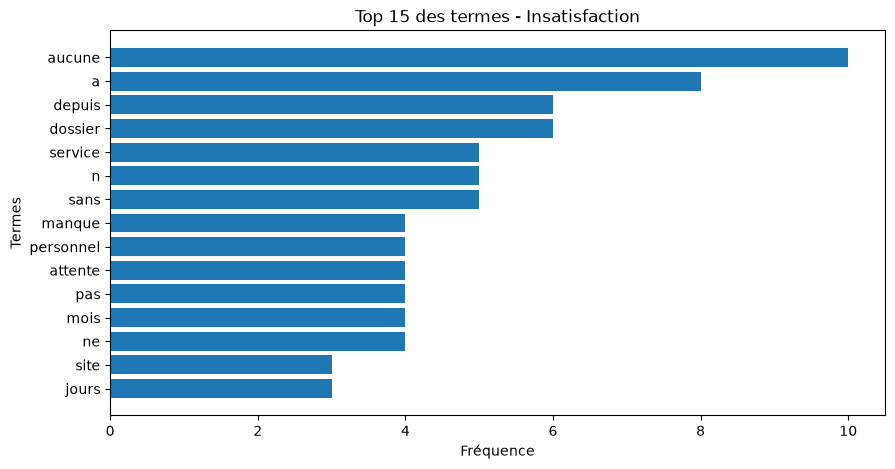

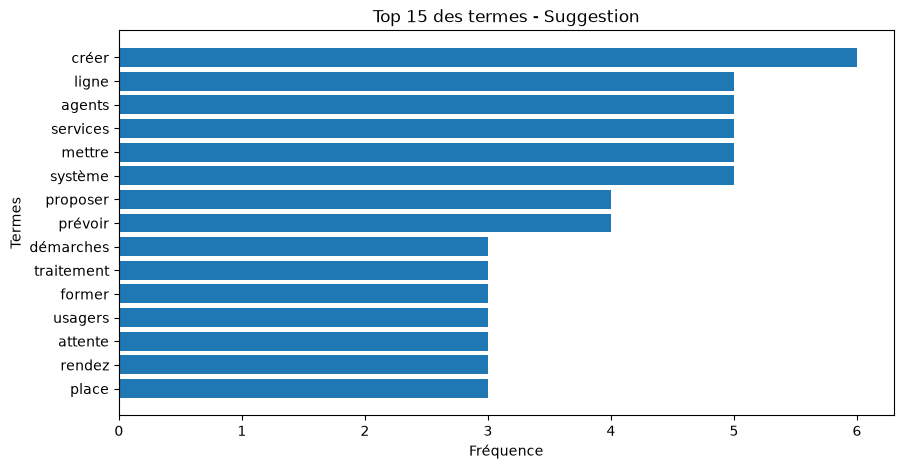

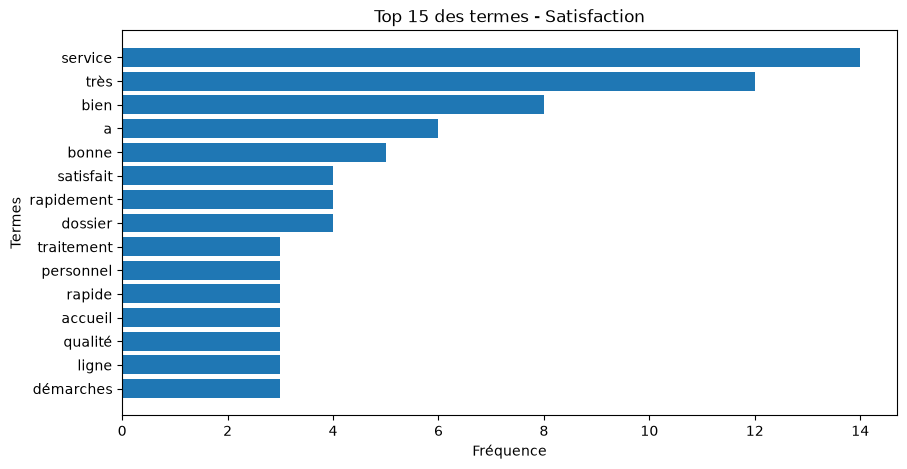

In [30]:
for categorie in df["categorie"].unique():
    textes = df[df["categorie"] == categorie]["texte_propre"]

    mots = " ".join(textes).split()
    frequences = Counter(mots)

    top_15 = frequences.most_common(15)

    termes = [mot for mot, freq in top_15]
    nombres = [freq for mot, freq in top_15]

    plt.figure(figsize=(10, 5))
    plt.barh(termes[::-1], nombres[::-1])
    plt.title(f"Top 15 des termes - {categorie}")
    plt.xlabel("Fréquence")
    plt.ylabel("Termes")
    plt.show()

Observation : Les termes les plus fréquents diffèrent selon les catégories. Certains mots sont associés aux expériences positives, d'autres aux difficultés rencontrées, tandis que la catégorie Suggestion fait davantage apparaître des termes liés aux propositions d'amélioration.

**visualisation de la longueur des textes**

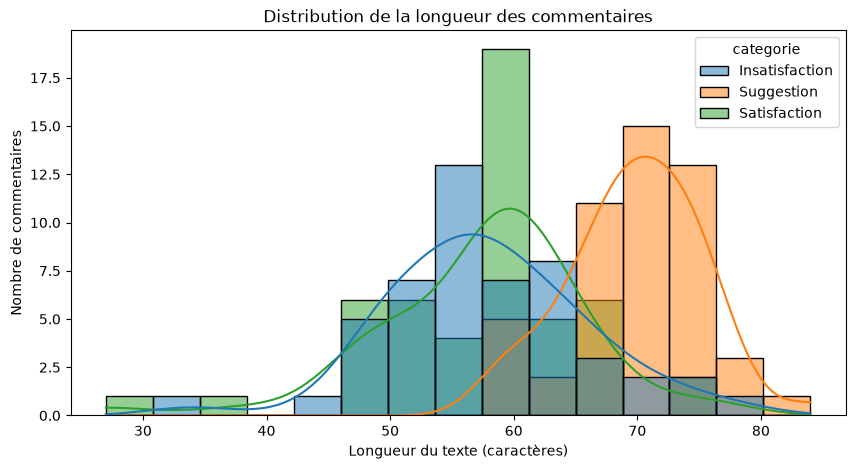

In [31]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="longueur_texte",
    hue="categorie",
    kde=True,
    bins=15
)

plt.title("Distribution de la longueur des commentaires")
plt.xlabel("Longueur du texte (caractères)")
plt.ylabel("Nombre de commentaires")

plt.show()

Observation : La longueur des commentaires varie selon les observations. La distribution permet de vérifier si certaines catégories contiennent principalement des commentaires courts ou longs. Cette information peut aider à comprendre certaines difficultés de classification.

**des exemples par catégorie**

In [32]:
for categorie in df["categorie"].unique():
    print(f"\n--- {categorie} ---")
    display(df[df["categorie"] == categorie][["id", "texte"]].head(3))


--- Insatisfaction ---


,id,texte
0,1,Manque total de communication entre les services.
4,5,Le formulaire en ligne plante au moment de la ...
5,6,Le personnel semble débordé et les citoyens en...



--- Suggestion ---


,id,texte
1,2,Il serait bien de proposer des tutoriels vidéo...
2,3,Envoyer des SMS de confirmation lors de chaque...
3,4,Prévoir des interprètes pour les citoyens ne p...



--- Satisfaction ---


,id,texte
7,8,J'ai été agréablement surpris par la rapidité ...
8,9,"Bonne expérience globale, les choses évoluent ..."
9,10,Le personnel fait preuve de beaucoup de profes...


**Partie 2 — Modélisation**

préparation de X et y

In [33]:
X = df["texte_propre"]
y = df["categorie"]

verification

In [34]:
print("Nombre de textes :", len(X))
print("Nombre de catégories :", y.nunique())
print("\nRépartition des catégories :")
print(y.value_counts())

Nombre de textes : 150
Nombre de catégories : 3

Répartition des catégories :
categorie
Insatisfaction    50
Suggestion        50
Satisfaction      50
Name: count, dtype: int64


séparation train/test

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

verification

In [36]:
print("Taille entraînement :", len(X_train))
print("Taille test :", len(X_test))

Taille entraînement : 120
Taille test : 30


Choix de la vectorisation : TF-IDF
La méthode TF-IDF a été choisie car elle est adaptée à un petit jeu de données textuelles et permet de représenter l'importance des termes dans chaque commentaire. Elle est également simple à interpréter et compatible avec les algorithmes classiques de classification.

In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer

creation du vecteur

In [38]:
vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=1
)

appele du TF-IDF sur les données d'entrainement

In [39]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

verification des dimention

In [40]:
print("Dimensions train :", X_train_tfidf.shape)
print("Dimensions test :", X_test_tfidf.shape)

Dimensions train : (120, 991)
Dimensions test : (30, 991)


2.2 — Premier modèle : Logistic Regression

In [41]:
from sklearn.linear_model import LogisticRegression

modele_lr = LogisticRegression(
    random_state=42,
    max_iter=1000
)

entrainement du model

In [42]:
modele_lr.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

faisons des prediction

In [43]:
y_pred_lr = modele_lr.predict(X_test_tfidf)

verification

In [44]:
print(y_pred_lr)

['Insatisfaction' 'Suggestion' 'Satisfaction' 'Satisfaction'
 'Insatisfaction' 'Insatisfaction' 'Insatisfaction' 'Suggestion'
 'Suggestion' 'Insatisfaction' 'Suggestion' 'Suggestion' 'Satisfaction'
 'Satisfaction' 'Suggestion' 'Insatisfaction' 'Insatisfaction'
 'Satisfaction' 'Satisfaction' 'Suggestion' 'Insatisfaction' 'Suggestion'
 'Satisfaction' 'Insatisfaction' 'Insatisfaction' 'Insatisfaction'
 'Satisfaction' 'Suggestion' 'Suggestion' 'Insatisfaction']


evaluation

In [45]:
from sklearn.metrics import accuracy_score, f1_score

accuracy_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="macro")

print("Accuracy :", accuracy_lr)
print("F1-score macro :", f1_lr)

Accuracy : 0.7
F1-score macro : 0.7047138047138047


matrice de confusion.

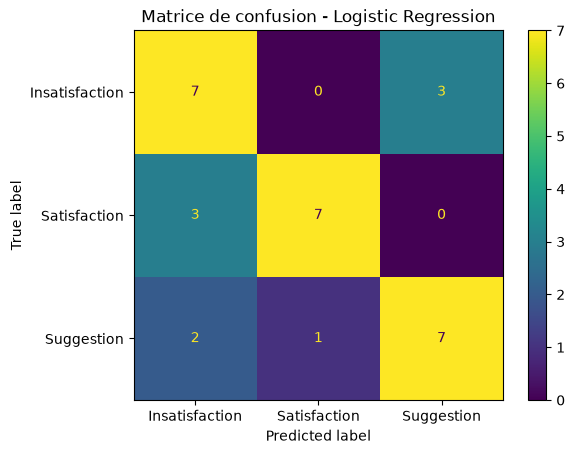

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=modele_lr.classes_
)

disp.plot()
plt.title("Matrice de confusion - Logistic Regression")
plt.show()

Analyse de la matrice de confusion :
La Logistic Regression classe correctement 22 commentaires sur 30. La catégorie Satisfaction est relativement bien reconnue avec 8 prédictions correctes sur 10. Les principales confusions concernent les catégories Insatisfaction et Suggestion. Trois commentaires réellement classés comme Insatisfaction sont prédits comme Suggestions, ce qui peut s'expliquer par la présence de formulations proposant des améliorations dans certains commentaires négatifs.

**2.3 deuxième modèle : Linear SVM**

In [47]:
from sklearn.svm import LinearSVC

modele_svm = LinearSVC(
    random_state=42
)

modele_svm.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [48]:
y_pred_svm = modele_svm.predict(X_test_tfidf)

calcule des deux score

In [49]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average="macro")

print("Accuracy :", accuracy_svm)
print("F1-score macro :", f1_svm)

Accuracy : 0.7333333333333333
F1-score macro : 0.7350168350168351


1. Vérifions la matrice de confusion du SVM

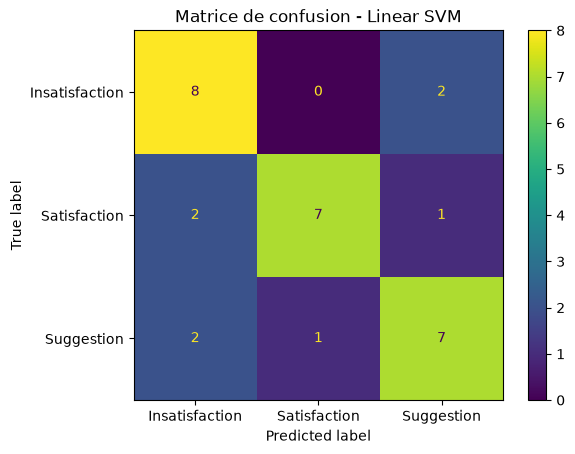

In [50]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=modele_svm.classes_
)

disp.plot()
plt.title("Matrice de confusion - Linear SVM")
plt.show()

2. Ensuite, faisons le tableau comparatif

In [51]:
resultats = pd.DataFrame({
    "Modèle": ["Logistic Regression", "Linear SVM"],
    "Accuracy": [accuracy_lr, accuracy_svm],
    "F1-score macro": [f1_lr, f1_svm]
})

resultats

,Modèle,Accuracy,F1-score macro
0,Logistic Regression,0.700000,0.704714
1,Linear SVM,0.733333,0.735017


Analyse comparative : Les deux modèles obtiennent les mêmes performances sur l'ensemble de test, avec une accuracy de 73,33 % et un F1-score macro de 0,7363. Pour ce découpage des données, les deux approches produisent donc des résultats identiques.

**l’analyse des erreurs texte en gras**

In [52]:
erreurs = pd.DataFrame({
    "texte": X_test,
    "vraie_categorie": y_test,
    "categorie_predite": y_pred_svm
})

erreurs = erreurs[erreurs["vraie_categorie"] != erreurs["categorie_predite"]]

erreurs

,texte,vraie_categorie,categorie_predite
19,agent patient écoute préoccupations,Satisfaction,Suggestion
52,manque personnel visible seulement guichets ou...,Insatisfaction,Suggestion
113,service numérique fonctionnel accessible depui...,Satisfaction,Insatisfaction
13,numériser archives retrouver rapidement ancien...,Suggestion,Satisfaction
89,ouvrir guichet spécial personnes âgées handica...,Suggestion,Insatisfaction
83,chatbot site officiel aiderait orienter usagers,Suggestion,Insatisfaction
99,agent a guidé pas pas démarche très apprécié,Satisfaction,Insatisfaction
49,n reçu aucun accusé réception demande,Insatisfaction,Suggestion


In [54]:
print("Nombre total d'erreurs :", len(erreurs))

Nombre total d'erreurs : 8


In [53]:
for i, ligne in erreurs.iterrows():
    print("\nTexte :", ligne["texte"])
    print("Vraie catégorie :", ligne["vraie_categorie"])
    print("Catégorie prédite :", ligne["categorie_predite"])
    print("-" * 80)


Texte : agent patient écoute préoccupations
Vraie catégorie : Satisfaction
Catégorie prédite : Suggestion
--------------------------------------------------------------------------------

Texte : manque personnel visible seulement guichets ouverts
Vraie catégorie : Insatisfaction
Catégorie prédite : Suggestion
--------------------------------------------------------------------------------

Texte : service numérique fonctionnel accessible depuis téléphone
Vraie catégorie : Satisfaction
Catégorie prédite : Insatisfaction
--------------------------------------------------------------------------------

Texte : numériser archives retrouver rapidement anciens dossiers
Vraie catégorie : Suggestion
Catégorie prédite : Satisfaction
--------------------------------------------------------------------------------

Texte : ouvrir guichet spécial personnes âgées handicapées
Vraie catégorie : Suggestion
Catégorie prédite : Insatisfaction
-----------------------------------------------------------

Analyse des erreurs de classification

L’analyse des erreurs montre que certaines confusions sont liées à l’ambiguïté des formulations et au faible nombre d’exemples disponibles pour l’apprentissage. Les commentaires courts contenant peu de marqueurs explicites de sentiment sont particulièrement difficiles à classifier. Certaines suggestions utilisent également un vocabulaire positif, tandis que certaines insatisfactions décrivent des problèmes de fonctionnement qui peuvent être proches du vocabulaire utilisé dans les propositions d’amélioration. Le modèle peut ainsi confondre les catégories Satisfaction, Insatisfaction et Suggestion.

# Classification de commentaires citoyens sur les services publics

## 1. Importation des bibliothèques

## 2. Chargement et exploration des données

### 2.1 Structure du dataset
### 2.2 Distribution des catégories
### 2.3 Longueur des commentaires

## 3. Prétraitement du texte

### 3.1 Mise en minuscules
### 3.2 Nettoyage des caractères
### 3.3 Tokenisation
### 3.4 Suppression des stopwords
### 3.5 Gestion des termes éwé/mina

## 4. Visualisation

### 4.1 WordCloud
### 4.2 Top 15 des termes

## 5. Modélisation

### 5.1 Préparation des données
### 5.2 Vectorisation TF-IDF
### 5.3 Logistic Regression
### 5.4 Linear SVM

## 6. Évaluation des modèles

### 6.1 Accuracy et F1-score
### 6.2 Matrice de confusion
### 6.3 Comparaison des modèles
### 6.4 Analyse des erreurs

## 7. Limites et pistes d'amélioration

## 8. Conclusion

Conclusion

Cette étude avait pour objectif de classifier automatiquement les commentaires citoyens en trois catégories : Satisfaction, Insatisfaction et Suggestion. Après une phase d’exploration et de prétraitement, les textes ont été représentés avec TF-IDF. Deux modèles de classification, Logistic Regression et Linear SVM, ont ensuite été entraînés et évalués. Les deux modèles ont obtenu une accuracy de 73,33 % et un F1-score macro de 0,7363 sur l’ensemble de test.

L’analyse des erreurs montre que certaines formulations courtes ou ambiguës sont difficiles à distinguer. La faible taille du dataset constitue également une limite importante.

Pistes d’amélioration :

Augmenter la taille et la diversité du dataset, notamment avec davantage de commentaires en éwé/mina.
Tester des représentations et modèles multilingues pré-entraînés tels que CamemBERT, mBERT ou XLM-R.

## 9. Sauvegarde du modèle pour l'application

In [55]:
import joblib

joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(modele_lr, "modele_logistic_regression.joblib")
joblib.dump(stopwords_fr, "stopwords_fr.joblib")

print("Vectoriseur et modèle sauvegardés avec succès.")

Vectoriseur et modèle sauvegardés avec succès.


verification des fichier

In [56]:
import os

print(os.listdir())

['.git', 'README.md', 'modele_logistic_regression.joblib', 'requirements.txt', 'dataset_nlp_test_tal.csv', 'notebook.ipynb', 'tfidf_vectorizer.joblib', 'stopwords_fr.joblib']
